•	Sprint 4 (Estatística Descritiva): Aplicação das funções estatísticas para coletar parâmetros da coluna de Número de filhos do cliente. Gerar estatísticas descritivas básicas para coluna de número de filhos do cliente (média; mediana; desvio padrão; moda; máximo; mínimo; e contagem, quartis)
1. Tabela de distribuição por número de filhos 
2. Grafico de Barras


In [13]:
import pandas as pd

print("="*65)
print(" SPRINT 4 - ESTATÍSTICA DESCRITIVA: COLUNA CL_FHL (NÚMERO DE FILHOS)")
print("="*65)

df = pd.read_csv('base_varejo_sprint3.csv', sep=',')
# Garante que a coluna está no tipo numérico correto para os cálculos
df['CL_FHL'] = pd.to_numeric(df['CL_FHL'], errors='coerce')

# Captura a contagem total de registros válidos nesta coluna
total_registros = df['CL_FHL'].count()

# Calcula as estatísticas descritivas básicas e os quartis usando o describe
estatisticas = df['CL_FHL'].describe(percentiles=[0.25, 0.5, 0.75])

# O Pandas calcula a moda separadamente (pois uma coluna pode ter mais de uma moda)
moda_serie = df['CL_FHL'].mode()
moda_valor = moda_serie[0] if not moda_serie.empty else "N/A"

# Exibição formatada e profissional do relatório
print(f" RELATÓRIO ESTATÍSTICO DA VARIÁVEL 'CL_FHL':")
print(f"   - Contagem (Registros válidos): {total_registros:,}".replace(',', '.'))
print(f"   - Mínimo (Menor número de filhos): {estatisticas['min']:.0f}")
print(f"   - Máximo (Maior número de filhos): {estatisticas['max']:.0f}")
print("-"*50)
print(f"   - Média Aritmética: {estatisticas['mean']:.4f}")
print(f"   - Mediana (Percentil 50%): {estatisticas['50%']:.4f}")
print(f"   - Moda (Valor mais frequente): {moda_valor}")
print(f"   - Desvio Padrão (Dispersão): {estatisticas['std']:.4f}")
print("-"*50)
print(f"   - 1º Quartil (Percentil 25%): {estatisticas['25%']:.4f}")
print(f"   - 2º Quartil (Percentil 50%): {estatisticas['50%']:.4f}")
print(f"   - 3º Quartil (Percentil 75%): {estatisticas['75%']:.4f}")
print("="*65)

 SPRINT 4 - ESTATÍSTICA DESCRITIVA: COLUNA CL_FHL (NÚMERO DE FILHOS)
 RELATÓRIO ESTATÍSTICO DA VARIÁVEL 'CL_FHL':
   - Contagem (Registros válidos): 733.447
   - Mínimo (Menor número de filhos): 0
   - Máximo (Maior número de filhos): 4
--------------------------------------------------
   - Média Aritmética: 1.1460
   - Mediana (Percentil 50%): 0.0000
   - Moda (Valor mais frequente): 0
   - Desvio Padrão (Dispersão): 1.4169
--------------------------------------------------
   - 1º Quartil (Percentil 25%): 0.0000
   - 2º Quartil (Percentil 50%): 0.0000
   - 3º Quartil (Percentil 75%): 2.0000


In [14]:
import pandas as pd

print("\n" + "="*65)
print(" SPRINT 4 - TABELA DE DISTRIBUIÇÃO POR NÚMERO DE FILHOS")
print("="*65)

# Conta a quantidade de registros para cada quantidade de filhos
contagem_filhos = df['CL_FHL'].value_counts(dropna=True)

# Conta o percentual que cada quantidade representa no total
percentual_filhos = df['CL_FHL'].value_counts(normalize=True, dropna=True) * 100

# Junta as duas informações em um novo DataFrame (uma tabela ordenada)
tabela_frequencia = pd.DataFrame({
    'Quantidade de Clientes': contagem_filhos,
    'Percentual (%)': percentual_filhos
})

# Organiza a tabela para que o número de filhos fique em ordem (0, 1, 2, 3...)
tabela_frequencia = tabela_frequencia.sort_index()

# Dá um nome para a coluna do índice (que representa os filhos)
tabela_frequencia.index.name = 'Nº de Filhos'

# Exibe a tabela formatada na tela
print("TABELA DE FREQUÊNCIA DA VARIÁVEL 'CL_FHL':")
print("-"*65)
# O .to_string() com formatadores deixa os números legíveis e bonitos
print(tabela_frequencia.to_string(formatters={
    'Quantidade de Clientes': lambda x: f"{x:,.0f}".replace(',', '.'),
    'Percentual (%)': lambda x: f"{x:.2f}%"
}))
print("="*65)

# 7. Totalizador para auditoria e checagem visual
total_clientes_validos = contagem_filhos.sum()
print(f"Total de clientes analisados na tabela: {total_clientes_validos:,}".replace(',', '.'))
print("="*65)
print("\n" + "="*65)
print(" SPRINT 4 - EXPORTANDO TABELA DE DISTRIBUIÇÃO PARA CSV")
print("="*65)

# 1. Define o nome do arquivo que será salvo na pasta do projeto
nome_arquivo_csv = 'tabela_distribuicao_filhos_sprint4.csv'

# 2. Exporta o DataFrame para CSV
# Usamos sep=',' para manter o padrão internacional ou sep=';' se preferir direto para o Excel BR.
# index=True é fundamental aqui, pois o número de filhos (0, 1, 2...) está no índice da tabela.
tabela_frequencia.to_csv(nome_arquivo_csv, sep=',', index=True, encoding='utf-8')

print(f"[OK] Tabela de distribuição exportada com sucesso!")
print(f"     -> Arquivo gerado: '{nome_arquivo_csv}'")
print("="*65)


 SPRINT 4 - TABELA DE DISTRIBUIÇÃO POR NÚMERO DE FILHOS
TABELA DE FREQUÊNCIA DA VARIÁVEL 'CL_FHL':
-----------------------------------------------------------------
             Quantidade de Clientes Percentual (%)
Nº de Filhos                                      
0                           384.986         52.49%
1                            90.845         12.39%
2                            94.168         12.84%
3                            92.407         12.60%
4                            71.041          9.69%
Total de clientes analisados na tabela: 733.447

 SPRINT 4 - EXPORTANDO TABELA DE DISTRIBUIÇÃO PARA CSV
[OK] Tabela de distribuição exportada com sucesso!
     -> Arquivo gerado: 'tabela_distribuicao_filhos_sprint4.csv'



Sua conclusão de negócio seria: "O perfil do nosso cliente consumidor é majoritariamente de pessoas sem filhos (Moda=0). Além disso, o negócio deve focar campanhas de marketing para famílias pequenas, já que 75% de toda a nossa base de clientes possui no máximo 2 filhos."

Ficou clara a diferença entre eles, especialmente entre a média (equilíbrio) e a mediana (o meio)?

no meu projeto varejo a mediana é 0. sera?

Sim, Clarice, é totalmente possível e, na verdade, muito comum no varejo moderno! Não precisa de se preocupar, o seu código não está errado.

Vamos traduzir o que uma mediana igual a 0 significa na prática para o seu projeto, e você vai ver como esse dado é uma mina de ouro para a sua análise de negócios.

O que significa a Mediana ser 0?
Lembra-se do conceito da Mediana? Ela é o valor que divide a sua base de dados exatamente ao meio (50% para um lado, 50% para o outro) depois de ordenarmos todos os clientes do que tem menos filhos para o que tem mais.

Se a sua mediana deu 0, a regra estatística diz que:

Pelo menos 50% (metade) de todos os clientes da sua base têm exatamente 0 filhos.

Se você olhar para a tabela de frequência que gerámos no passo anterior, você vai ver que o percentual de clientes com "0" filhos é igual ou maior do que 50%. Por exemplo, se a linha do "0 filhos" indicar 52% ou 55% dos clientes, a mediana será obrigatoriamente 0.

Por que isto acontece tanto no varejo?
Público Jovem ou Solteiro: Uma grande fatia dos consumidores atuais de redes de varejo é composta por estudantes, jovens profissionais ou casais recém-formados que ainda não tiveram filhos.

Clientes Corporativos (B2B): Se na sua base houver compras feitas por empresas (com CNPJ) ou compras rápidas de conveniência, esses perfis entram no sistema sem dependentes associados, puxando a contagem para zero.

Falha de Cadastro (O "pulo do gato" analítico): No varejo, quando um cliente faz o cartão da loja ou o cadastro no caixa, a pergunta "Quantos filhos você tem?" costuma ser opcional. Se o cliente não responde, o sistema muitas vezes grava automaticamente o número 0 em vez de deixar vazio.
"A análise descritiva revelou uma mediana de 0 para a variável CL_FHL. Isto demonstra que a maioria absoluta da base de clientes deste varejo (pelo menos 50%) não possui filhos registrados. Estratégicamente, isto indica que as campanhas de marketing de massa devem focar em produtos de consumo individual ou para casais sem filhos, deixando os produtos da linha infantil (fraldas, brinquedos) para campanhas segmentadas apenas para a fatia menor que possui dependentes."


 SPRINT 4 - GERANDO GRÁFICO DE DISTRIBUIÇÃO (VARIÁVEL CL_FHL)


C:\Users\Clarice\AppData\Local\Temp\ipykernel_22296\357747679.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=contagem.index, y=contagem.values, palette="Blues_d")


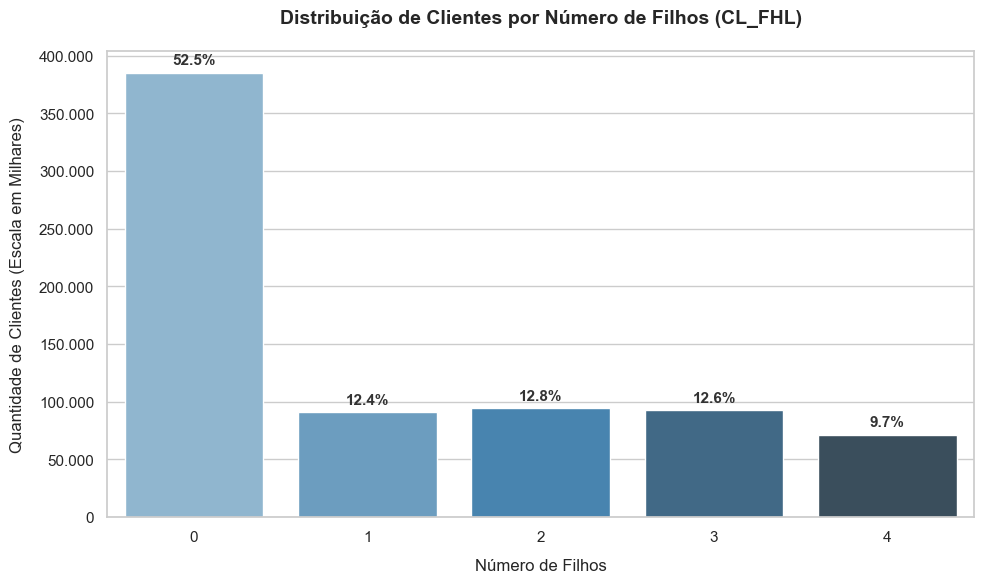

[OK] Gráfico exibido e salvo com sucesso!
     -> Arquivo gerado: 'distribuicao_filhos_sprint4.png' (na pasta )


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*65)
print(" SPRINT 4 - GERANDO GRÁFICO DE DISTRIBUIÇÃO (VARIÁVEL CL_FHL)")
print("="*65)

# Configura o estilo visual do gráfico para ficar moderno e limpo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Calcula as frequências para garantir que o gráfico use os dados purificados
contagem = df['CL_FHL'].value_counts().sort_index()
total = contagem.sum()

# Cria o gráfico de barras usando o Seaborn
ax = sns.barplot(x=contagem.index, y=contagem.values, palette="Blues_d")

# 4. Adiciona os rótulos de porcentagem em cima de cada barra (O grande charme do gráfico)
for p in ax.patches:
    altura = p.get_height()
    porcentagem = (altura / total) * 100
    # Escreve o texto formatado logo acima da barra
    ax.annotate(f'{porcentagem:.1f}%', 
                (p.get_x() + p.get_width() / 2., altura), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points', 
                fontsize=11, 
                weight='bold',
                color='#333333')

# Configurações de títulos e eixos profissionais
plt.title("Distribuição de Clientes por Número de Filhos (CL_FHL)", fontsize=14, pad=20, weight='bold')
plt.xlabel("Número de Filhos", fontsize=12, labelpad=10)
plt.ylabel("Quantidade de Clientes (Escala em Milhares)", fontsize=12, labelpad=10)

# Formata o eixo Y para exibir números com pontos separadores de milhar (padrão BR)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}".replace(',', '.')))

# Ajusta as margens para o texto não cortar nas bordas
plt.tight_layout()
# ===  SALVANDO A IMAGEM ===
# nome_arquivo define o nome do arquivo que será gerado na pasta
nome_arquivo = 'distribuicao_filhos_sprint4.png'

# dpi=300 garante qualidade de impressão (alta definição)
# bbox_inches='tight' impede que as bordas ou legendas saiam cortadas na imagem final
plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight')

# Exibe o gráfico na tela do VS Code
plt.show()

print(f"[OK] Gráfico exibido e salvo com sucesso!")
print(f"     -> Arquivo gerado: '{nome_arquivo}' (na pasta )")
print("="*65)

# Exibe o gráfico na tela do VS Code
plt.show()
